In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

import pickle

In [2]:
df = pd.read_csv("creditcard.csv")
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [4]:
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True))

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


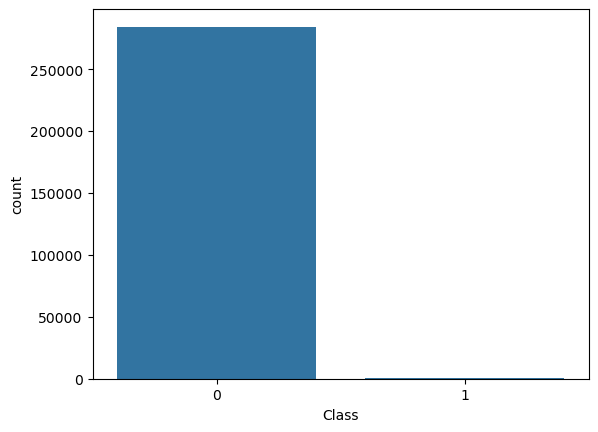

In [5]:
sns.countplot(x='Class', data=df)
plt.show()

In [6]:
X = df.drop(["Class", "Time"], axis=1)
y = df["Class"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # 🔥 important for imbalance
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (227845, 29)
Test shape: (56962, 29)


In [8]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


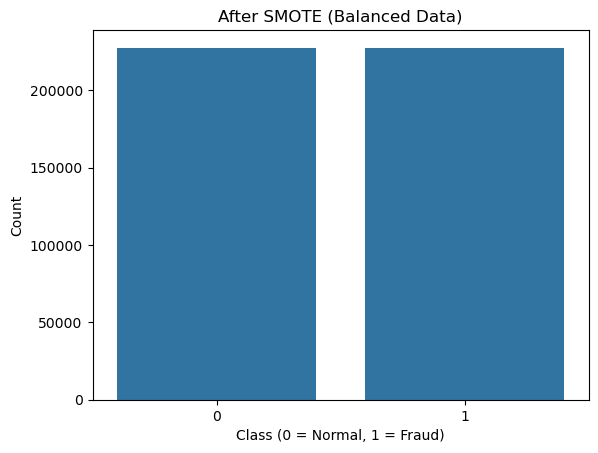

In [9]:
sns.countplot(x=y_train_smote.values)
plt.title("After SMOTE (Balanced Data)")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train_smote)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Scaling done ✅")

Scaling done ✅


In [11]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train_smote)

print("Logistic Regression trained ✅")

Logistic Regression trained ✅


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))  
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nClassification Report:\n")  
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
Accuracy: 0.9994733330992591
Precision: 0.8469387755102041
Recall: 0.8469387755102041
F1 Score: 0.8469387755102041

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.85      0.85        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [13]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [14]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(eval_metric='logloss')

xgb_model.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb_model.predict(X_test)

print("🔹 XGBoost Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))

🔹 XGBoost Results:
Accuracy: 0.999420666409185
Precision: 0.8037383177570093
Recall: 0.8775510204081632
F1 Score: 0.8390243902439024


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("🔹 Random Forest Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

🔹 Random Forest Evaluation:
Accuracy: 0.9994733330992591
Precision: 0.8469387755102041
Recall: 0.8469387755102041
F1 Score: 0.8469387755102041


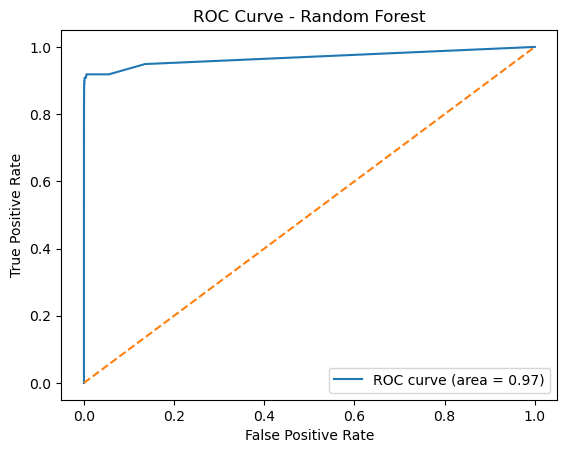

In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.show()

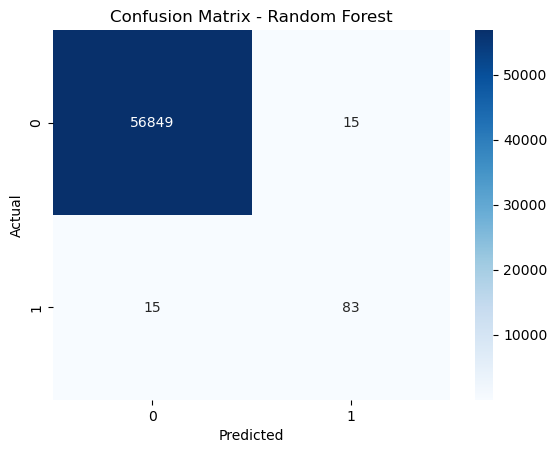

In [17]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

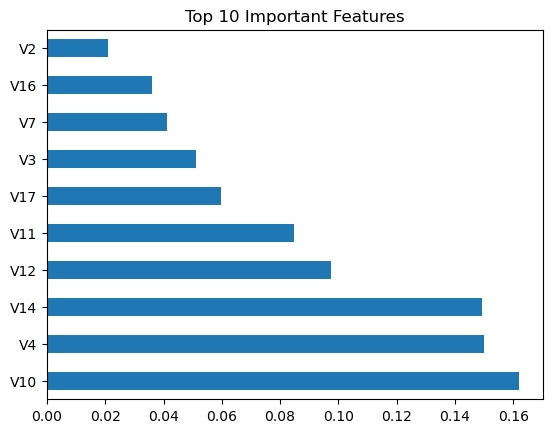

In [18]:
import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)

feature_importance.nlargest(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=2,
    n_jobs=-1
)

grid.fit(X_train_smote, y_train_smote)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}


In [20]:
import pickle

pickle.dump(
    rf_model,
    open(r"C:\Users\91808\OneDrive\Desktop\fraud_detection_project\model\fraud_model.pkl", "wb")
)

print("Model saved in correct folder ✅")

Model saved in correct folder ✅


In [22]:
import os
print(os.getcwd())

C:\Users\91808


In [23]:
fraud_sample = X_test[y_test == 1].iloc[0].values
fraud_sample

array([-1.27124419,  2.46267527, -2.851395  ,  2.32448007, -1.37224489,
       -0.94819569, -3.06523436,  1.16692695, -2.26877059, -4.88114293,
        2.25514749, -4.6863869 ,  0.65237467, -6.17428835,  0.59437961,
       -4.84969239, -6.53652074, -3.11909388,  1.71549442,  0.56047808,
        0.65294105,  0.08193098, -0.22134783, -0.52358216,  0.22422816,
        0.75633452,  0.63280048,  0.25018709,  0.01      ])

In [24]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
fraud_sample = X_test[y_test == 1].iloc[0].values
print(fraud_sample)

[ 5.70070000e+04 -1.27124419e+00  2.46267527e+00 -2.85139500e+00
  2.32448007e+00 -1.37224489e+00 -9.48195687e-01 -3.06523436e+00
  1.16692695e+00 -2.26877059e+00 -4.88114293e+00  2.25514749e+00
 -4.68638690e+00  6.52374669e-01 -6.17428835e+00  5.94379608e-01
 -4.84969239e+00 -6.53652074e+00 -3.11909388e+00  1.71549442e+00
  5.60478076e-01  6.52941051e-01  8.19309764e-02 -2.21347831e-01
 -5.23582159e-01  2.24228162e-01  7.56334523e-01  6.32800477e-01
  2.50187093e-01  1.00000000e-02]
